### Imports

In [563]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pulp import LpProblem, LpVariable, LpBinary, lpSum, LpMinimize, PULP_CBC_CMD, GLPK_CMD

np.random.seed(42)

### Sampling e, f and g

* We use a Multivariate Gaussian to sample e,f and g values with the specified covariance between them 

In [564]:
# Number of instances
N = 500

#### Parameters

In [565]:
mean = [0.2, 0.4]
cov = [[0.2,-0.1], [-0.1, 0.2]] 

In [566]:
points = np.random.multivariate_normal(mean, cov, N)

gi = np.clip(points[:, 0], 0, 1)
fi = np.clip(points[:, 1], 0, 1)


# sample ei from uniform distribution
ei = np.random.uniform(0.5, 1, N)

### Budget

In [567]:
# Budget can also be determined as a percentage of N
BUDGET_PERC = 0.2
B = np.sum(ei) * BUDGET_PERC

### Solve the LP to get allocations

In [568]:
# Cost coefficients
c = fi - gi

# Initialize problem
prob = LpProblem("Expert_Assignment_ILP", LpMinimize)

# Decision variables: Xi ∈ {0, 1}
X = [LpVariable(f'X_{i}', cat=LpBinary) for i in range(N)]

# Objective: minimize sum(gi + Xi*(fi - gi)) = constant + sum(Xi*(fi - gi))
prob += lpSum([c[i] * X[i] for i in range(N)])

# Constraint: total effort used by expert ≤ B
prob += lpSum([ei[i] * X[i] for i in range(N)]) <= B

# Solve
prob.solve(PULP_CBC_CMD(msg=1))  # Silent mode

# Extract results
Xi = np.array([int(X[i].varValue) if X[i].varValue is not None else 0 for i in range(N)])

### Allocation Visualization for All or Nothing using Integer Linear Program

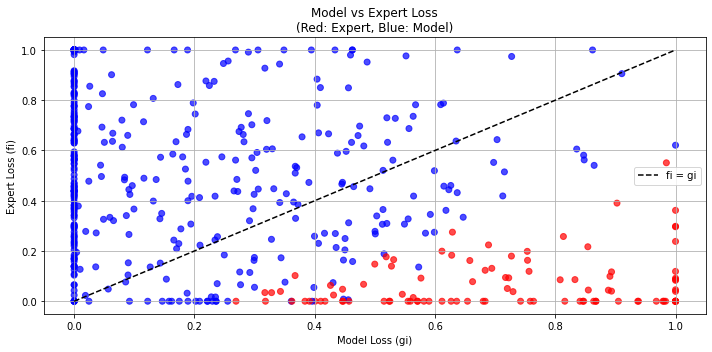

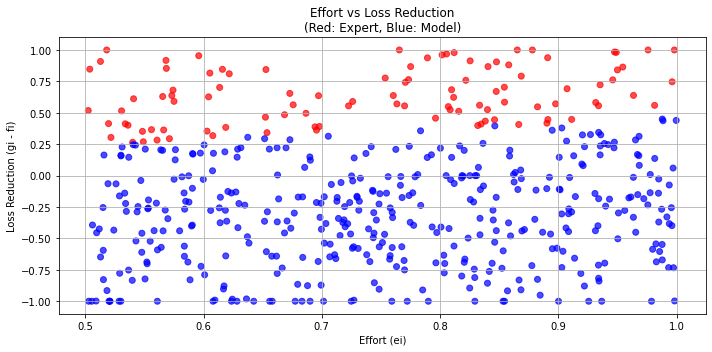

In [569]:
# DataFrame for analysis
df = pd.DataFrame({
    'gi': gi,
    'fi': fi,
    'ei': ei,
    'Xi': Xi
})
df['AssignedToExpert'] = df['Xi'] == 1

colors = ['red' if x else 'blue' for x in df['AssignedToExpert']]

# === Visualization 1: Model vs Expert Loss ===
plt.figure(figsize=(10, 5))
plt.scatter(df['gi'], df['fi'], c=colors, alpha=0.7)
plt.plot([0, 1], [0, 1], 'k--', label='fi = gi')
plt.xlabel('Model Loss (gi)')
plt.ylabel('Expert Loss (fi)')
plt.title('Model vs Expert Loss\n(Red: Expert, Blue: Model)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# === Visualization 2: Effort vs Loss Reduction ===
plt.figure(figsize=(10, 5))
plt.scatter(df['ei'], df['gi'] - df['fi'], c=colors, alpha=0.7)
plt.xlabel('Effort (ei)')
plt.ylabel('Loss Reduction (gi - fi)')
plt.title('Effort vs Loss Reduction\n(Red: Expert, Blue: Model)')
plt.grid(True)
plt.tight_layout()
# plt.legend()
plt.show()

### Average Expert Assignment on Varying budget

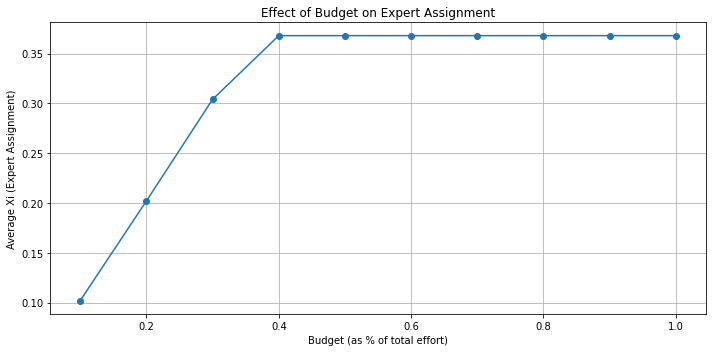

In [570]:
budget_range = np.linspace(0.1, 1.0, 10)  # Budget from 10% to 100% of total effort
results = []
for budget in budget_range:
    # Solve the linear program for each budget
    Budget = np.sum(ei) * budget
    
    prob = LpProblem("Expert_Assignment_ILP", LpMinimize)

    # Decision variables: Xi ∈ {0, 1}
    X = [LpVariable(f'X_{i}', cat=LpBinary) for i in range(N)]

    # Objective: minimize sum(gi + Xi*(fi - gi)) = constant + sum(Xi*(fi - gi))
    prob += lpSum([c[i] * X[i] for i in range(N)])

    # Constraint: total effort used by expert ≤ B
    prob += lpSum([ei[i] * X[i] for i in range(N)]) <= Budget

    # Solve
    prob.solve(PULP_CBC_CMD(msg=0))  # Silent mode

    # Extract results
    Xi = np.array([X[i].varValue for i in range(N)], dtype=int)
    
    results.append((budget, Xi))
    
results_df = pd.DataFrame(results, columns=['Budget', 'Xi'])
results_df['Xi'] = results_df['Xi'].apply(lambda x: np.mean(x))  # Average Xi for each budget

# Plotting the results
plt.figure(figsize=(10, 5))
plt.plot(results_df['Budget'], results_df['Xi'], marker='o')
plt.xlabel('Budget (as % of total effort)')
plt.ylabel('Average Xi (Expert Assignment)')
plt.title('Effect of Budget on Expert Assignment')
plt.grid(True)
plt.tight_layout()
plt.show()

### Using fractional Knapsack for solving

In [571]:
wi=ei
vi=gi-fi
eff_ratio=vi/wi
Xi=np.zeros(N)
sorted_indices = np.argsort(eff_ratio)[::-1]  # Sort indices by efficiency ratio in descending order
threshold_er=0
curr=0

for i in sorted_indices:
    if curr + wi[i] <= B and eff_ratio[i] > 0:
        curr+=wi[i]
        Xi[i]=1
    else:
        threshold_er=eff_ratio[i]
        break


In [572]:
expected_error=np.sum(Xi*fi+(1-Xi)*gi)/N
print(np.sum(Xi)/len(Xi))
print(expected_error)

0.202
0.16305131187434982


### Allocation Visualization for All or Nothing Scheme using fractional knapsack

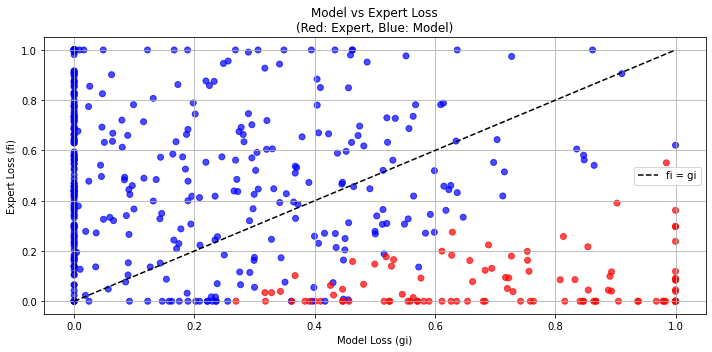

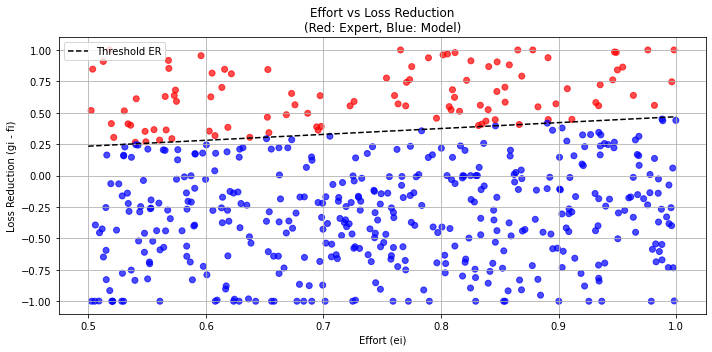

In [573]:
# DataFrame for analysis
df = pd.DataFrame({
    'gi': gi,
    'fi': fi,
    'ei': ei,
    'Xi': Xi
})
df['AssignedToExpert'] = df['Xi'] == 1

colors = ['red' if x else 'blue' for x in df['AssignedToExpert']]

# === Visualization 1: Model vs Expert Loss ===
plt.figure(figsize=(10, 5))
plt.scatter(df['gi'], df['fi'], c=colors, alpha=0.7)
plt.plot([0, 1], [0, 1], 'k--', label='fi = gi')
plt.xlabel('Model Loss (gi)')
plt.ylabel('Expert Loss (fi)')
plt.title('Model vs Expert Loss\n(Red: Expert, Blue: Model)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# === Visualization 2: Effort vs Loss Reduction ===
plt.figure(figsize=(10, 5))
plt.scatter(df['ei'], df['gi'] - df['fi'], c=colors, alpha=0.7)
# plt.plot([0, 1], [0, 1- 2*BUDGET_PERC], 'k--', label='Loss Reduction = 0')
plt.xlabel('Effort (ei)')
plt.ylabel('Loss Reduction (gi - fi)')
plt.title('Effort vs Loss Reduction\n(Red: Expert, Blue: Model)')
plt.grid(True)
plt.tight_layout()
plt.plot([0.5, 1], [threshold_er/2, threshold_er], 'k--', label='Threshold ER')
plt.legend()
plt.show()

### Heuristic Based Allocation

#### Choosing the curves

In [574]:
def linear_accuracy_with_effort(ei, fi, effort):
    fi_new=1-(1-fi)*effort/ei
    return fi_new

def convex_accuracy_with_effort(ei, fi, effort,deg=3):
    fi_new=(1-fi)*((1-effort/ei)**deg)+(fi)
    return fi_new

def concave_accuracy_with_effort(ei, fi, effort,deg=3):
    fi_new=1-(1-fi)*(effort/ei)**deg
    return fi_new

def exponential_concave_accuracy_with_effort(ei, fi, effort):
    fi_new=(fi)**(effort/ei)
    return fi_new

def exponential_convex_accuracy_with_effort(ei, fi, effort):
    fi_new=2-(2-(fi))**(effort/ei)
    return fi_new

Text(0, 0.5, 'Human error')

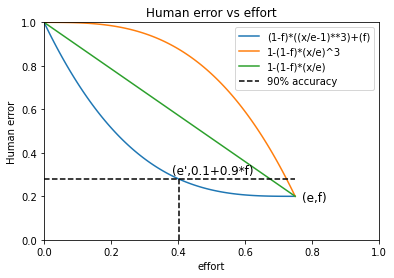

In [575]:
e=0.75
f=0.2

x = np.linspace(0, e, 100)
# y= exponential_convex_accuracy_with_effort(e, f, x)
# plt.plot(x, y, label='f^(x/e)')

# y=  exponential_concave_accuracy_with_effort(e, f, x)
# plt.plot(x, y, label='2-(2-f)^(x/e)')

# y= convex_accuracy_with_effort(e, f, x, 2)
# plt.plot(x, y, label='(1-f)*((x/e-1)**2)+(f)')

y= convex_accuracy_with_effort(e, f, x, 3)
plt.plot(x, y, label='(1-f)*((x/e-1)**3)+(f)')

# y= concave_accuracy_with_effort(e, f, x, 2)
# plt.plot(x, y, label='1-(1-f)*(x/e)^2')

y= concave_accuracy_with_effort(e, f, x, 3)
plt.plot(x, y, label='1-(1-f)*(x/e)^3')


y=linear_accuracy_with_effort(e, f, x)  
plt.plot(x, y, label='1-(1-f)*(x/e)')


plt.text(e+0.02, f-0.02, '(e,f)', fontsize=12)

# plt.annotate('(e,f)', xy=(e, f), xytext=(e+0.05, f-0.05),
#              arrowprops=dict(facecolor='black', arrowstyle='->'))
# plt.scatter(e, f, color='red', label='(e,f)')
f_prime = 0.1 + 0.9*f
e_prime = e*(1-0.1**(1/3))
plt.plot([0, e] , [f_prime, f_prime] , 'k--', label='90% accuracy')
plt.text(e_prime-0.02, f_prime+0.02, "(e',0.1+0.9*f)", fontsize=12)
plt.plot([e_prime, e_prime] , [0, f_prime] , 'k--')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.title('Human error vs effort')
plt.xlabel('effort')
plt.ylabel('Human error')


#### Allocation and error

0.17913399117389064 83


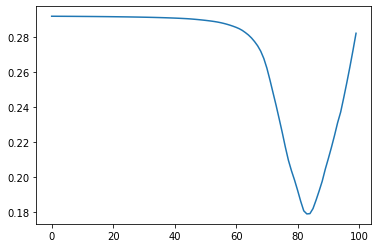

In [576]:
errors=np.ones(100)

for a in range(0, 100):
    alpha = a / 100
    beta   = 1-alpha
    effort = np.full(N, B / (N * beta))
    effort = np.minimum(effort, ei)  # Ensure effort does not exceed ei
    

    ###### CHANGE this to the desired function ######
    fi_new=concave_accuracy_with_effort(ei, fi, effort)
    #####################################################


    t_alpha=fi_new-gi
    Xi=np.zeros(N)
    Xi[np.argsort(t_alpha)[:int(N*beta)]]=1


    Xi[t_alpha>0]=0


    error=np.sum(Xi*fi_new+(1-Xi)*gi)/N
    errors[a]=error
plt.plot(range(0,100), errors)

print(errors.min(),errors.argmin())

##### minor optimisation


0.16930840955778756 80


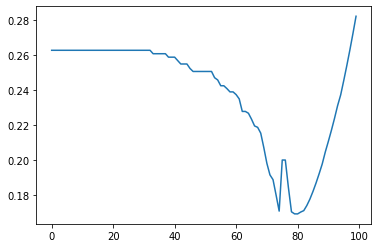

In [577]:
errors=np.ones(100)

for a in range(0, 100):
    alpha = a / 100
    beta   = 1-alpha
    effort = np.full(N, B / (N * beta))
    effort = np.minimum(effort, ei)  # Ensure effort does not exceed ei
    

    ###### CHANGE this to the desired function ######
    fi_new=concave_accuracy_with_effort(ei, fi, effort)
    #####################################################

    t_alpha=fi_new-gi
    Xi=np.zeros(N)
    Xi[np.argsort(t_alpha)[:int(N*beta)]]=1



#############
    effort[Xi==0] = 0  # Set effort to 0 for selected experts
    for i in range(10):
        effort=(effort*B)/(effort.sum())  # Normalize effort to sum to 1
        effort = np.minimum(effort, ei)  # Ensure effort does not exceed ei
    fi_new=concave_accuracy_with_effort(ei, fi, effort)  # Recalculate fi_new based on normalized effort

    t_alpha=fi_new-gi
    Xi[t_alpha>0]=0

    effort[Xi==0] = 0  # Set effort to 0 for selected experts
    for i in range(10):
        effort=(effort*B)/(effort.sum())  # Normalize effort to sum to 1
        effort = np.minimum(effort, ei)  # Ensure effort does not exceed ei
    fi_new=concave_accuracy_with_effort(ei, fi, effort)  # Recalculate fi_new based on normalized effort
    
##############



    error=np.sum(Xi*fi_new+(1-Xi)*gi)/N
    errors[a]=error
plt.plot(range(0,100), errors)

print(errors.min(),errors.argmin())

### Allocation Visualization for equal effort distibution scheme

In [582]:

alpha = 80 / 100
beta   = 1-alpha
effort = np.full(N, B / (N * beta))
effort = np.minimum(effort, ei)  # Ensure effort does not exceed ei

fi_new=concave_accuracy_with_effort(ei, fi, effort)
t_alpha=fi_new-gi
Xi=np.zeros(N)
Xi[np.argsort(t_alpha)[:int(N*beta)]]=1
Xi[t_alpha>0]=0
error=np.sum(Xi*fi_new+(1-Xi)*gi)/N
print(np.sum(Xi)/len(Xi))
print(error)

0.198
0.1925598944373948


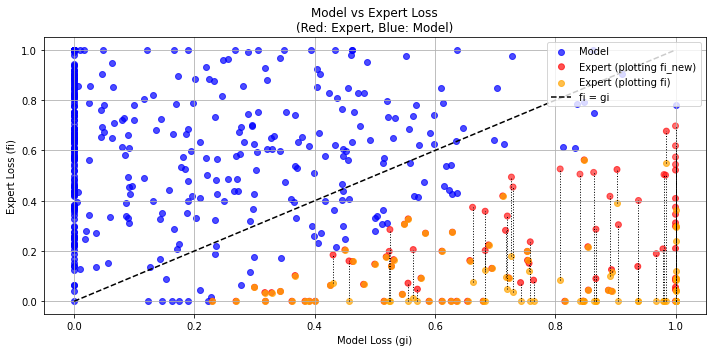

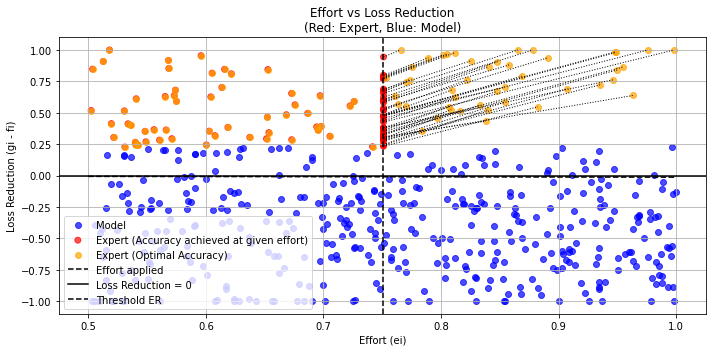

In [583]:
# DataFrame for analysis
df = pd.DataFrame({
    'gi': gi,
    'fi': fi,
    'fi_new': fi_new,
    'ei': ei,
    'Xi': Xi,
    'effort': effort,
})

df['AssignedToExpert'] = df['Xi'] == 1

# === Visualization 1: Model vs Expert Loss ===
# Separate red (expert) and blue (model) points
expert_df = df[df['AssignedToExpert']]
model_df = df[~df['AssignedToExpert']]

# Plot
plt.figure(figsize=(10, 5))
# Blue points: fixed alpha
plt.scatter(model_df['gi'], model_df['fi_new'], color='blue', alpha=0.7, label='Model')
# Red points: variable alpha
plt.scatter(expert_df['gi'], expert_df['fi_new'],
            color='red',
            alpha=0.7*np.exp((expert_df['effort'] / expert_df['ei'] ) -1),
            label='Expert (plotting fi_new)')

plt.scatter(expert_df['gi'], expert_df['fi'],
            color='orange',
            alpha=0.7,
            label='Expert (plotting fi)')

for _, row in expert_df.iterrows():
    plt.plot([row['gi'], row['gi']],
             [row['fi'], row['fi_new']],
             'k:', linewidth=1) 
    
plt.plot([0, 1], [0, 1], 'k--', label='fi = gi')
plt.xlabel('Model Loss (gi)')
plt.ylabel('Expert Loss (fi)')
plt.title('Model vs Expert Loss\n(Red: Expert, Blue: Model)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



# === Visualization 2: Effort vs Loss Reduction ===
plt.figure(figsize=(10, 5))
plt.scatter(model_df['ei'], model_df['gi']-model_df['fi_new'], color='blue', alpha=0.7, label='Model')

plt.scatter(expert_df['effort'], expert_df['gi']-expert_df['fi_new'],
            color='red',
            alpha=0.7*np.exp((expert_df['effort'] / expert_df['ei'] ) -1),
            label='Expert (Accuracy achieved at given effort)')

plt.scatter(expert_df['ei'], expert_df['gi']-expert_df['fi'],
            color='orange',
            alpha=0.7,
            label='Expert (Optimal Accuracy)')

for _, row in expert_df.iterrows():
    plt.plot([row['effort'], row['ei']],
             [row['gi']-row['fi_new'], row['gi']-row['fi']],
             'k:', linewidth=1) 

plt.axvline(x=expert_df['effort'].max(), color='k', linestyle='--', label='Effort applied')
plt.axhline(y=0, color='k', linestyle='-', label='Loss Reduction = 0')
plt.xlabel('Effort (ei)')
plt.ylabel('Loss Reduction (gi - fi)')
plt.title('Effort vs Loss Reduction\n(Red: Expert, Blue: Model)')
plt.grid(True)
plt.tight_layout()
# plt.xlim(0, 1)
# plot a line from 0,0 to 1,threshold_er
plt.plot([0.5, 1], [threshold_er/2, threshold_er], 'k--', label='Threshold ER')
plt.legend()
# plt.ylim(0, 1)
plt.show()

### 90% Accuracy Allocation For convex case

In [584]:
wi=ei*(1-0.1**(1/3))
vi=gi-(fi*0.9+0.1)

eff_ratio=vi/wi
Xi=np.zeros(N)
sorted_indices = np.argsort(eff_ratio)[::-1]  # Sort indices by efficiency ratio in descending order
threshold_er=0
curr=0

for i in sorted_indices:
    if curr + wi[i] <= B and eff_ratio[i] > 0:
        curr+=wi[i]
        Xi[i]=1
    else:
        threshold_er=eff_ratio[i]
        break

In [585]:
expected_error=np.sum(Xi*fi+(1-Xi)*gi)/N
print(np.sum(Xi)/len(Xi))
print(expected_error)

0.348
0.12990322635590376
